# TFT sobre los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Importar fft de scipy
from scipy.fft import fft, ifft

In [19]:
df_tft = { 
    'ch1': [132036, 132239, 132317, 132358, 132449, 132719, 132804, 132959, 133039, 133128],
    'ch2': [132202, 132252, 132335, 132409, 132458, 132742, 132814, 133016, 133052, 133145],
    'dx': [7.62e-6, 7.62e-6, 7.62e-6, 7.62e-6, 7.62e-6, 0.152, 0.152, 3.04e-3, 3.04e-3, 3.04e-3]
}
df_tft = pd.DataFrame(df_tft)


In [20]:
df_tft

,ch1,ch2,dx
0,132036,132202,0.000008
1,132239,132252,0.000008
2,132317,132335,0.000008
3,132358,132409,0.000008
4,132449,132458,0.000008
5,132719,132742,0.152000
6,132804,132814,0.152000
7,132959,133016,0.003040
8,133039,133052,0.003040
9,133128,133145,0.003040


In [31]:
datos_ch1 = pd.read_excel(f"D:/Documents/Nacho/FACU/data-analysis-physics/electromagnetism/Datos Marcelo/132036.xls", skiprows=7).iloc[:, 1]
datos_ch2 = pd.read_excel(f"D:/Documents/Nacho/FACU/data-analysis-physics/electromagnetism/Datos Marcelo/132202.xls", skiprows=7).iloc[:, 0]
#dx = df_tft['dx']
datos_ch1 = datos_ch1.apply(pd.to_numeric, errors='coerce').dropna().values
datos_ch2 = datos_ch2.apply(pd.to_numeric, errors='coerce').dropna().values
datos_ch1

array([  640,   480,   800,  1520, -1440,   560,     0,   640,   880,
         480, -1120,    80,  -240, -1920,  -320,   -80, -1440,  -560,
         480,  -720,  -160,   880, -1040, -1440,  -560,  -240,   160,
        -640,  1280,  -400,   -80,  1600,  -400,   400,    80, -1920,
       -1440,  -400,   960,  -800, -1760, -1280,    80, -1040,  -560,
       -2000,   160,  1600,   800,  1280,  1200,  -880,  1600,   800,
       -2320,  -800,  2080,  -400, -1040,   480,   960,  1200,   240,
         160,  -320,  -640, -1840,  -560, -1040,  -720,  -160,  -400,
       -1280,  1120,  -240,  -320,  -880,   560, -2080, -1360,   640,
        -160,   880, -1360,  -640,   240,  -560,   800,   960, -1120,
        -560, -1200,   -80,  1440,  -320, -1840,   320, -1600,   400,
        -640, -1280, -1840,  -160,  1200, -1680,   160,  -320,   480,
        -960,  1200,   720, -1760,   960, -1040,   880,  1040,   640,
          80,  -560, -1360,   160,  -960,  -400,  1840,  1040,   640,
        -400, -1040,

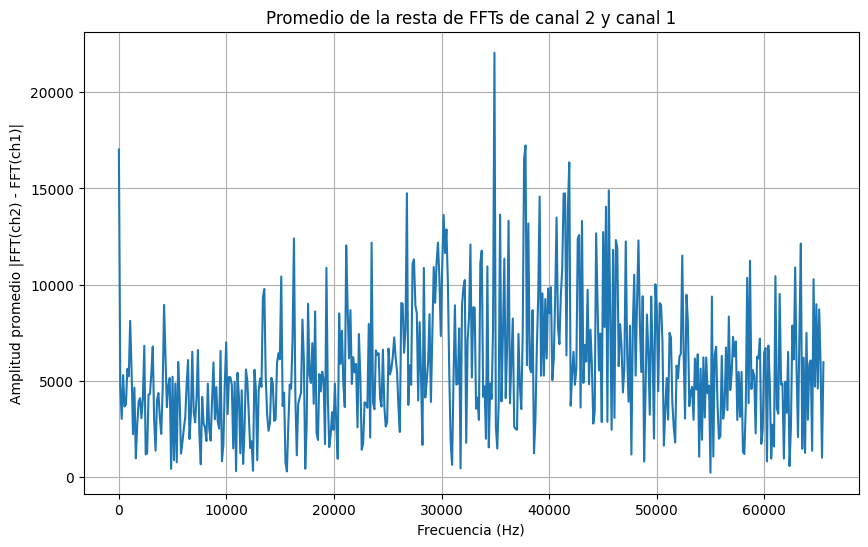

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft

# Supongamos que df_tft tiene las rutas de los archivos en las columnas 'ch1' y 'ch2'
# y el paso de tiempo en 'dx'

restas_fft = []

for idx, row in df_tft.iterrows():
    # Leer los datos de cada canal (ajusta según el formato real de tus archivos)
    datos_ch1 = pd.read_excel(f"D:/Documents/Nacho/FACU/data-analysis-physics/electromagnetism/Datos Marcelo/{int(row['ch1'])}.xls", skiprows=7).iloc[:, 1]
    datos_ch2 = pd.read_excel(f"D:/Documents/Nacho/FACU/data-analysis-physics/electromagnetism/Datos Marcelo/{int(row['ch2'])}.xls", skiprows=7).iloc[:, 1]
    dx = row['dx']
    datos_ch1 = datos_ch1.apply(pd.to_numeric, errors='coerce').dropna().values
    datos_ch2 = datos_ch2.apply(pd.to_numeric, errors='coerce').dropna().values
    # Asegúrate de que ambos tengan la misma longitud
    min_len = min(len(datos_ch1), len(datos_ch2))
    if min_len == 0:
        continue  # Saltar si alguno de los canales está vacío
    datos_ch1 = datos_ch1[:min_len]
    datos_ch2 = datos_ch2[:min_len]
    
    # FFT de ambos canales
    fft_ch1 = fft(datos_ch1)
    fft_ch2 = fft(datos_ch2)
    
    # Resta y almacena
    resta = fft_ch2 - fft_ch1
    restas_fft.append(resta)

# Convertir la lista a un array 2D para promediar
restas_fft = np.array(restas_fft)

# Promediar sobre todos los pares (eje 0)
promedio_resta = np.mean(restas_fft, axis=0)

# Calcular frecuencias para el eje x usando el dx del primer archivo (puedes ajustar esto)
n = len(promedio_resta)
dx = df_tft.iloc[0]['dx']
frecuencias = np.fft.fftfreq(n, d=dx)

# Graficar solo la parte positiva del espectro
mask = frecuencias >= 0
plt.figure(figsize=(10,6))
plt.plot(frecuencias[mask], np.abs(promedio_resta[mask]))
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud promedio |FFT(ch2) - FFT(ch1)|')
plt.title('Promedio de la resta de FFTs de canal 2 y canal 1')
plt.grid(True)
plt.show()

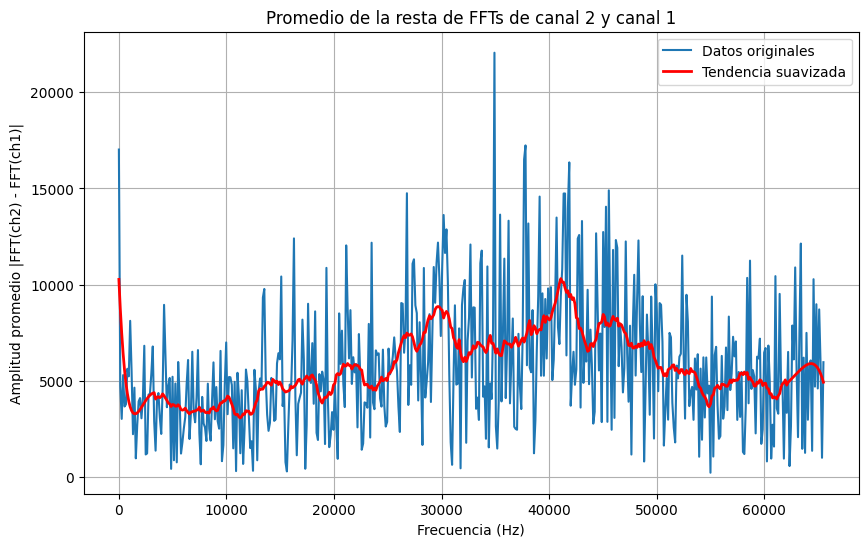

In [36]:
from scipy.signal import savgol_filter

# Suponiendo que ya tienes: frecuencias[mask], np.abs(promedio_resta[mask])
y = np.abs(promedio_resta[mask])
x = frecuencias[mask]

# Aplica un filtro de Savitzky-Golay para suavizar la tendencia
# window_length debe ser impar y menor que el tamaño de y, polyorder es el grado del polinomio
y_smooth = savgol_filter(y, window_length=51, polyorder=5)

plt.figure(figsize=(10,6))
plt.plot(x, y, label='Datos originales')
plt.plot(x, y_smooth, color='red', linewidth=2, label='Tendencia suavizada')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud promedio |FFT(ch2) - FFT(ch1)|')
plt.title('Promedio de la resta de FFTs de canal 2 y canal 1')
plt.grid(True)
plt.legend()
plt.show()

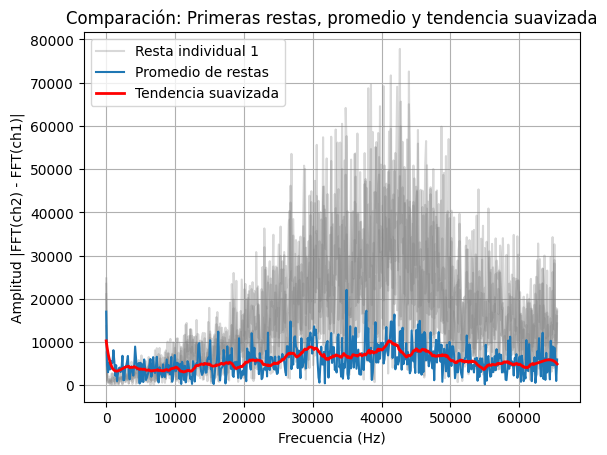

In [45]:
from scipy.signal import savgol_filter

# Datos para el promedio y la tendencia
y = np.abs(promedio_resta[mask])
x = frecuencias[mask]

# Tendencia suavizada
y_smooth = savgol_filter(y, window_length=51, polyorder=5)
# Graficar las primeras 3 restas individuales de fondo
for i in range(5):
    resta_individual = np.abs(restas_fft[i][mask])
    plt.plot(x, resta_individual, color='gray', alpha=0.3, label=f'Resta individual {i+1}' if i == 0 else None)

plt.plot(x, y, label='Promedio de restas')
plt.plot(x, y_smooth, color='red', linewidth=2, label='Tendencia suavizada')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud |FFT(ch2) - FFT(ch1)|')
plt.title('Comparación: Primeras restas, promedio y tendencia suavizada')
plt.grid(True)
plt.legend()
plt.show()


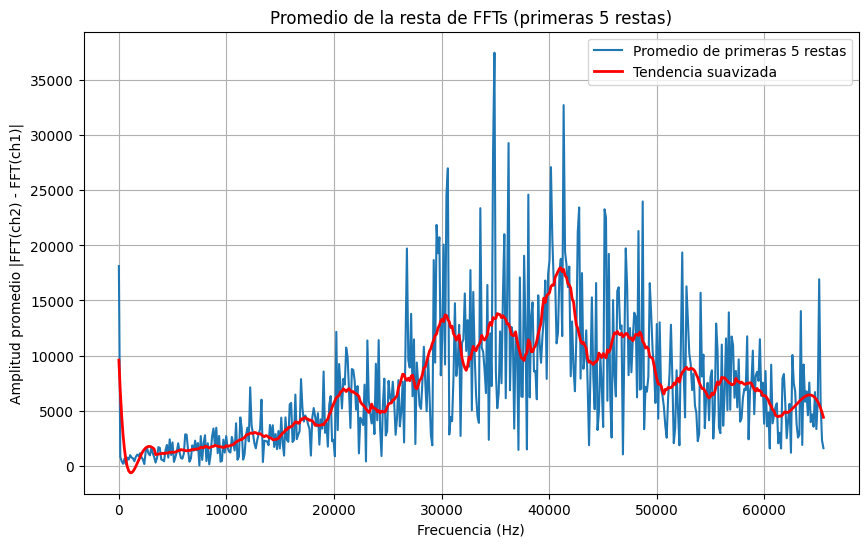

In [43]:
from scipy.signal import savgol_filter

# Tomar solo las primeras 5 restas
restas_fft_5 = restas_fft[:5]

# Calcular el promedio de las primeras 5 restas
promedio_resta_5 = np.mean(restas_fft_5, axis=0)

# Calcular frecuencias para el eje x usando el dx del primer archivo
n = len(promedio_resta_5)
dx = df_tft.iloc[0]['dx']
frecuencias = np.fft.fftfreq(n, d=dx)

# Graficar solo la parte positiva del espectro
mask = frecuencias >= 0
x = frecuencias[mask]
y = np.abs(promedio_resta_5[mask])

# Suavizado
y_smooth = savgol_filter(y, window_length=51, polyorder=5)

plt.figure(figsize=(10,6))
plt.plot(x, y, label='Promedio de primeras 5 restas')
plt.plot(x, y_smooth, color='red', linewidth=2, label='Tendencia suavizada')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud promedio |FFT(ch2) - FFT(ch1)|')
plt.title('Promedio de la resta de FFTs (primeras 5 restas)')
plt.grid(True)
plt.legend()
plt.show()

Text(0.5, 1.0, 'Promedios de la resta de FFTs por grupos')

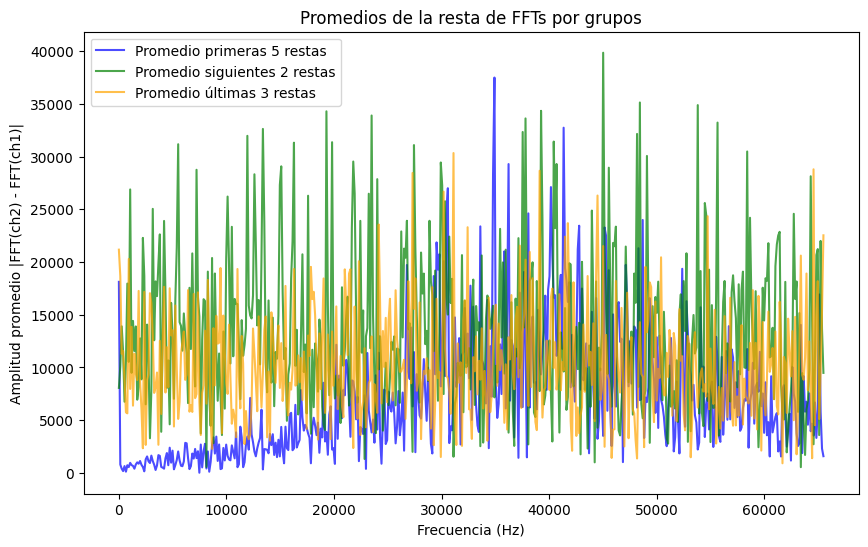

In [55]:
from scipy.signal import savgol_filter

# Calcular promedios de los grupos indicados
restas_fft_5 = restas_fft[:5]
restas_fft_2 = restas_fft[5:7]
restas_fft_3 = restas_fft[7:10]

promedio_5 = np.mean(restas_fft_5, axis=0)
promedio_2 = np.mean(restas_fft_2, axis=0)
promedio_3 = np.mean(restas_fft_3, axis=0)

# Calcular frecuencias para el eje x usando el dx del primer archivo
n = len(promedio_5)
dx = df_tft.iloc[0]['dx']
frecuencias = np.fft.fftfreq(n, d=dx)
mask = frecuencias >= 0
x = frecuencias[mask]

# Obtener los valores de amplitud para cada grupo
y_5 = np.abs(promedio_5[mask])
y_2 = np.abs(promedio_2[mask])
y_3 = np.abs(promedio_3[mask])

# Datos total
y = np.abs(promedio_resta[mask])
# Tendencia suavizada
y_smooth = savgol_filter(y, window_length=51, polyorder=5)



# Graficar
plt.figure(figsize=(10,6))
#plt.plot(x, y, label='Promedio de restas', zorder=10, color='black')
#plt.plot(x, y_smooth, color='red', linewidth=2, label='Tendencia suavizada', zorder=11)
plt.plot(x, y_5, color='blue', alpha=0.7, label='Promedio primeras 5 restas')
plt.plot(x, y_2, color='green', alpha=0.7, label='Promedio siguientes 2 restas')
plt.plot(x, y_3, color='orange', alpha=0.7, label='Promedio últimas 3 restas')
plt.xlabel('Frecuencia (Hz)')
plt.legend()
plt.ylabel('Amplitud promedio |FFT(ch2) - FFT(ch1)|')
plt.title('Promedios de la resta de FFTs por grupos')